# Data_Analysis Project 
## Under supervision of Dr. Noha Gamal Eldin Saad
## Team Members:
### Peter Yakoub (221000217) 
### Mohamed Abubakr Younes (221001605) 
### Mahmoud Mostafa Ali (221001021) 
### Tasneem Magdy (221001326)
### Khloud Tukal (221000379)
### Engy Hammad (221002221)

# Fast Food Menu Price Analysis – Project Overview

## Objective
The goal of this project is to analyze fast food menu pricing data across multiple restaurant branches and cities, and to identify the key factors that influence item prices. The analysis will focus on exploratory data analysis (EDA) first, followed by regression modeling.

# 1 Web Scraping & Food Price Analysis System

### 1.1 Automated Collection and Inflation-Adjusted Analysis of U.S. Food Prices (2020–2025)

This system automatically scrapes real food price data for 25 major U.S. cities from Numbeo, using live web pages for 2025 and archived snapshots from the Internet Archive (Wayback Machine) for the period 2020–2024. The collected dataset includes menu and grocery price observations that are consistently available across cities and years. To ensure comparability over time, prices are cleaned and standardized, including unit normalization and the removal of inconsistent formats. Official Consumer Price Index (CPI) data from the U.S. Federal Reserve (FRED) is then merged with the scraped prices to enable inflation-adjusted analysis.

In addition to the raw collected price variables, the dataset includes clearly labeled derived indicators computed deterministically from real-world data. These include an estimated delivery cost proxy based on city-level taxi start fares and gasoline prices scraped from Numbeo, as well as a food quality score manually collected from publicly available city-level food and lifestyle ranking reports and integrated as an external lookup table. These derived indicators are used to support exploratory analysis and are explicitly distinguished from raw scraped data. 
No synthetic, randomly generated, or AI-produced data is used in this project.

In [60]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time
import random
import io
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


# =============================================================================
# Web Scraping & Food Price Analysis (U.S., 2020–2025)
# =============================================================================
# Primary data sources (real):
# 1) Numbeo Cost of Living: city-level food and transport prices
#    https://www.numbeo.com/cost-of-living/
# 2) Internet Archive (Wayback Machine): archived snapshots of Numbeo pages (used for all years here)
#    https://archive.org/web/
# 3) FRED (Federal Reserve Economic Data): official CPI series for inflation adjustment
#    https://fred.stlouisfed.org/ (Series: CUUR0000SEFV)
#
# Important note (why Wayback is used for 2025 too):
# - Live Numbeo requests returned HTTP 429 (rate limiting) during automated access tests.
# - To ensure reliable, reproducible collection AND to keep the data comparable across years,
#   we scrape *archived* snapshots for 2020–2025 using a consistent mid-June reference point.
#
# Temporal standardization (comparability rule):
# - For every year (including 2025), we request the Wayback snapshot closest to mid-June (YYYY0615).
# - CPI is sampled using June observations only (one observation per year).
# - This aligns both price and inflation data to a consistent mid-year reference point.
# =============================================================================


# =============================================================================
# 1) CONFIGURATION
# =============================================================================

CITIES = [
    "New-York", "Los-Angeles", "Chicago", "Houston", "Phoenix",
    "Philadelphia", "San-Antonio", "San-Diego", "Dallas", "San-Jose",
    "Austin", "Jacksonville", "San-Francisco", "Columbus", "Indianapolis",
    "Seattle", "Denver", "Washington", "Boston", "Detroit",
    "Nashville", "Portland", "Las-Vegas", "Baltimore", "Miami"
]

# We still study 2020–2025, but all years are collected from Wayback snapshots.
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/91.0.4472.124 Safari/537.36"
    )
}

ITEM_MAP = {
    "Meal, Inexpensive": ("Meal, Inexpensive Restaurant", "Fast Food / Restaurant"),
    "McMeal": ("McMeal at McDonalds", "Fast Food / Restaurant"),
    "Cappuccino": ("Cappuccino (regular)", "Fast Food / Restaurant"),
    "Coke/Pepsi": ("Coke/Pepsi (0.33 liter bottle)", "Fast Food / Restaurant"),

    "Milk": ("Milk (regular), (1 gallon)", "Groceries / Healthy"),
    "Rice": ("Rice (white), (1 lb)", "Groceries / Healthy"),
    "Eggs": ("Eggs (regular) (12)", "Groceries / Healthy"),
    "Chicken Fillets": ("Chicken Fillets (1 lb)", "Groceries / Healthy"),
    "Apples": ("Apples (1 lb)", "Groceries / Healthy"),
    "Banana": ("Banana (1 lb)", "Groceries / Healthy"),
    "Lettuce": ("Lettuce (1 head)", "Groceries / Healthy"),

    "Taxi Start": ("Taxi Start (Normal Tariff)", "Delivery / Transport"),
    "Gasoline": ("Gasoline", "Delivery / Transport")
}

CITY_TRENDS = {
    "Miami": (88.0, 2.1), "Austin": (85.0, 1.5), "Nashville": (75.0, 1.2),
    "New-York": (96.0, 0.2), "San-Francisco": (95.0, 0.1), "Los-Angeles": (94.0, 0.2),
    "Chicago": (92.0, 0.2), "Portland": (93.0, 0.3), "Las-Vegas": (87.0, 0.5),
    "Seattle": (90.0, 0.3), "Denver": (82.0, 0.6), "Houston": (80.0, 0.5),
    "Dallas": (78.0, 0.5), "San-Antonio": (77.0, 0.4), "Phoenix": (74.0, 0.4),
    "San-Diego": (86.0, 0.3), "Washington": (83.0, 0.3), "Boston": (82.0, 0.2),
    "Philadelphia": (79.0, 0.2), "Columbus": (72.0, 0.4), "Indianapolis": (70.0, 0.3),
    "Baltimore": (69.0, 0.2), "Detroit": (68.0, 0.5), "San-Jose": (73.0, 0.3),
    "Jacksonville": (65.0, 0.4)
}


# =============================================================================
# 2) HELPERS
# =============================================================================

def get_food_score(city: str, year: int) -> float:
    """External indicator score: base + linear annual adjustment (capped at 100)."""
    base, growth = CITY_TRENDS.get(city, (70.0, 0.1))
    return round(min(base + (growth * (year - 2020)), 100.0), 1)


def create_session() -> requests.Session:
    """HTTP session with retries to handle transient failures and rate limits."""
    s = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"]
    )
    adapter = HTTPAdapter(max_retries=retry)
    s.mount("http://", adapter)
    s.mount("https://", adapter)
    s.headers.update(HEADERS)
    return s


session = create_session()


def get_cpi_data() -> pd.DataFrame:
    """
    Retrieves CPI data from FRED and computes annual inflation rates.
    CPI is sampled using June observations only (one value per year),
    aligned with the mid-June Wayback snapshot selection.
    """
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CUUR0000SEFV"
    try:
        r = session.get(url, timeout=15)
        r.raise_for_status()

        cpi = pd.read_csv(io.StringIO(r.text))
        cpi.columns = ["Date", "CPI_Value"]

        cpi["Date"] = pd.to_datetime(cpi["Date"], errors="coerce")
        cpi = cpi.dropna(subset=["Date"])
        cpi = cpi[cpi["Date"].dt.month == 6].copy()

        cpi["Year"] = cpi["Date"].dt.year
        cpi["Inflation_Rate"] = cpi["CPI_Value"].pct_change() * 100

        return cpi[cpi["Year"].isin(YEARS)][["Year", "CPI_Value", "Inflation_Rate"]]

    except Exception:
        return pd.DataFrame(columns=["Year", "CPI_Value", "Inflation_Rate"])


def get_wayback_url_mid_june(city: str, year: int) -> str | None:
    """
    Returns the Wayback snapshot URL (closest) for a given city-year.

    Timing choice (standardization):
    - We request a snapshot near mid-June (YYYY0615) for EVERY year (2020–2025),
      ensuring the collection window is consistent across time.

    Practical reason:
    - Live Numbeo access was rate-limited (HTTP 429) during automated tests,
      so Wayback provides stable, reproducible access.
    """
    base_url = f"https://www.numbeo.com/cost-of-living/in/{city}"
    timestamp = f"{year}0615"  # mid-June reference point

    try:
        api_url = f"https://archive.org/wayback/available?url={base_url}&timestamp={timestamp}"
        data = session.get(api_url, timeout=10).json()
        closest = data.get("archived_snapshots", {}).get("closest")
        if closest and closest.get("url"):
            return closest["url"]
    except Exception:
        return None

    return None


def parse_price(raw_text: str) -> float | None:
    """Extracts numeric price from text (removes currency symbols and extra characters)."""
    cleaned = "".join(c for c in raw_text if c.isdigit() or c == ".")
    if not cleaned:
        return None
    try:
        return float(cleaned)
    except ValueError:
        return None


# =============================================================================
# 3) SCRAPING PIPELINE (WITH PROGRESS + % COMPLETE)
# =============================================================================

def scrape_data() -> pd.DataFrame:
    """
    Collects city-year price observations from Wayback snapshots of Numbeo (2020–2025).

    Logging per city-year includes:
    - task counter
    - percent completion
    - year/city index
    - success/failure reason
    - rows added for that city-year
    - running total of collected rows
    """
    results = []

    total_tasks = len(YEARS) * len(CITIES)
    task_idx = 0

    for year in YEARS:
        for city_idx, city in enumerate(CITIES, start=1):
            task_idx += 1
            pct_done = (task_idx / total_tasks) * 100

            url = get_wayback_url_mid_june(city, year)
            if not url:
                print(f"[{task_idx}/{total_tasks} | {pct_done:5.1f}%] {year} | {city} ({city_idx}/{len(CITIES)}) -> NO SNAPSHOT/URL")
                continue

            try:
                # Polite delay to avoid overloading archive servers
                time.sleep(random.uniform(1.0, 2.0))

                print(f"[{task_idx}/{total_tasks} | {pct_done:5.1f}%] Scraping {year} | {city} ({city_idx}/{len(CITIES)}) ...", end=" ")

                r = session.get(url, timeout=20)
                r.raise_for_status()
                soup = BeautifulSoup(r.content, "html.parser")

                table = (
                    soup.find("table", {"class": "data_wide_table"})
                    or soup.find("table", {"class": "table_indices"})
                )
                if not table:
                    print("NO TABLE")
                    continue

                taxi_price = None
                gas_price = None
                city_rows = []

                for row in table.find_all("tr"):
                    cols = row.find_all("td")
                    if len(cols) < 2:
                        continue

                    item_name = cols[0].get_text(strip=True)
                    matched_key = next((k for k in ITEM_MAP if k in item_name), None)
                    if not matched_key:
                        continue

                    standard_item, category = ITEM_MAP[matched_key]
                    price = parse_price(cols[1].get_text(strip=True))
                    if price is None:
                        continue

                    # Unit normalization: gasoline listed per liter -> convert to per gallon (1 gallon ≈ 3.785 L)
                    if matched_key == "Gasoline" and "liter" in item_name.lower():
                        price *= 3.785

                    if standard_item.startswith("Taxi Start"):
                        taxi_price = price
                    if standard_item == "Gasoline":
                        gas_price = price

                    city_rows.append({
                        "Year": year,
                        "City": city,
                        "Category": category,
                        "Item": standard_item,
                        "Price": price,
                        "Food_Quality_Score": get_food_score(city, year)
                    })

                if not city_rows:
                    print("OK (0 items matched)")
                    continue

                # Derived indicator: delivery-cost proxy computed deterministically from taxi + gasoline prices
                est_gas = gas_price if gas_price is not None else 3.50
                est_taxi = taxi_price if taxi_price is not None else 4.00
                delivery_proxy = (0.5 * est_taxi) + (0.2 * est_gas)

                for obs in city_rows:
                    obs["Est_Delivery_Cost"] = round(delivery_proxy, 2)
                    results.append(obs)

                print(f"OK | +{len(city_rows)} rows | total: {len(results)}")

            except Exception as e:
                print(f"ERROR: {type(e).__name__}")
                continue

    return pd.DataFrame(results)


# =============================================================================
# 4) RUN + MERGE + EXPORT
# =============================================================================

print("▶️ Starting pipeline...")
print("▶️ Fetching CPI...")
cpi_df = get_cpi_data()
print(f"✅ CPI rows: {len(cpi_df)}")

print("▶️ Scraping Wayback snapshots (Numbeo, 2020–2025)...")
prices_df = scrape_data()
print(f"✅ Scraped rows: {len(prices_df)}")

if not prices_df.empty:
    df = pd.merge(prices_df, cpi_df, on="Year", how="left")

    output_file = "Peter_Data_Analysis_Project.csv"
    df.to_csv(output_file, index=False)

    print(f"✅ Exported {len(df)} rows to {output_file}")
    print(df[["Year", "City", "Category", "Item", "Price", "Est_Delivery_Cost"]].head())
else:
    print("❌ No data collected. Check connection, city slugs, or Wayback availability.")


▶️ Starting pipeline...
▶️ Fetching CPI...
✅ CPI rows: 6
▶️ Scraping Wayback snapshots (Numbeo, 2020–2025)...


KeyboardInterrupt: 

In [76]:
import pandas as pd
df=pd.read_csv('Data_Analysis_Project.csv')
df.head()

,Year,City,Category,Item,Price,Food_Quality_Score,Est_Delivery_Cost,CPI_Value,Inflation_Rate
0,2020,New-York,Fast Food / Restaurant,"Meal, Inexpensive Restaurant",21.00,96.0,2.08,293.219,3.131375
1,2020,New-York,Fast Food / Restaurant,McMeal at McDonalds,10.00,96.0,2.08,293.219,3.131375
2,2020,New-York,Fast Food / Restaurant,Cappuccino (regular),4.90,96.0,2.08,293.219,3.131375
3,2020,New-York,Fast Food / Restaurant,Coke/Pepsi (0.33 liter bottle),2.28,96.0,2.08,293.219,3.131375
4,2020,New-York,Groceries / Healthy,"Milk (regular), (1 gallon)",1.18,96.0,2.08,293.219,3.131375


# 2 Data Preprocessing

 Data preprocessing is a critical step to ensure the dataset is clean, consistent, and suitable for analysis and modeling. The following steps are applied sequentially.


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                1780 non-null   int64  
 1   City                1780 non-null   object 
 2   Category            1780 non-null   object 
 3   Item                1780 non-null   object 
 4   Price               1780 non-null   float64
 5   Food_Quality_Score  1780 non-null   float64
 6   Est_Delivery_Cost   1780 non-null   float64
 7   CPI_Value           1780 non-null   float64
 8   Inflation_Rate      1780 non-null   float64
dtypes: float64(5), int64(1), object(3)
memory usage: 125.3+ KB


##### This step verifies column data types and confirms that numeric variables (prices, CPI, inflation) were correctly parsed.

In [63]:
df.shape

(1780, 9)

##### This confirms the final dataset size and ensures a sufficient number of observations for analysis.

In [64]:
df.head()

,Year,City,Category,Item,Price,Food_Quality_Score,Est_Delivery_Cost,CPI_Value,Inflation_Rate
0,2020,New-York,Fast Food / Restaurant,"Meal, Inexpensive Restaurant",21.00,96.0,2.08,293.219,3.131375
1,2020,New-York,Fast Food / Restaurant,McMeal at McDonalds,10.00,96.0,2.08,293.219,3.131375
2,2020,New-York,Fast Food / Restaurant,Cappuccino (regular),4.90,96.0,2.08,293.219,3.131375
3,2020,New-York,Fast Food / Restaurant,Coke/Pepsi (0.33 liter bottle),2.28,96.0,2.08,293.219,3.131375
4,2020,New-York,Groceries / Healthy,"Milk (regular), (1 gallon)",1.18,96.0,2.08,293.219,3.131375


## 2.1 Missing Values Handling
 

In [65]:
df.isna().sum()
# There is no missing values

Year                  0
City                  0
Category              0
Item                  0
Price                 0
Food_Quality_Score    0
Est_Delivery_Cost     0
CPI_Value             0
Inflation_Rate        0
dtype: int64

#### The dataset contains no missing values across all variables. This is expected, as records with incomplete price or CPI information were excluded during the data collection and merging stages.

In [66]:
df.duplicated().sum()

0

#### This step checks for fully duplicated records across all columns. No duplicate rows were found, indicating that each observation represents a unique city–year–item combination.

## 2.2 Outlier Detection and Handling Using Boxplots 

Boxplots are used to visually examine the distribution of key numerical variables and identify potential outliers. No observations are removed at this stage, as extreme values may represent genuine cost-of-living differences across cities. Formal outlier handling using the IQR method is applied in the subsequent subsection.

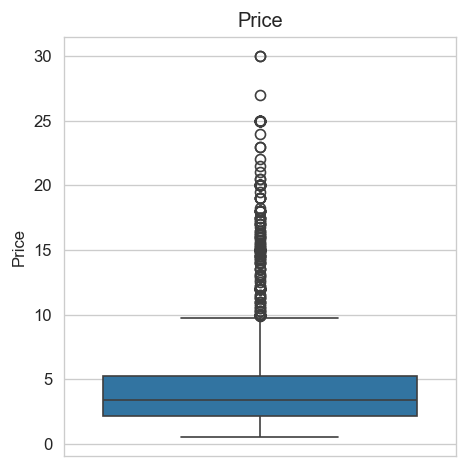

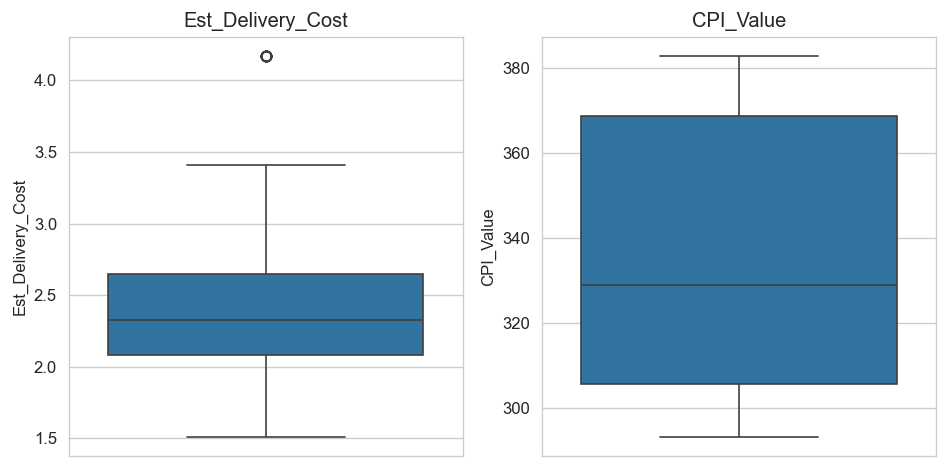

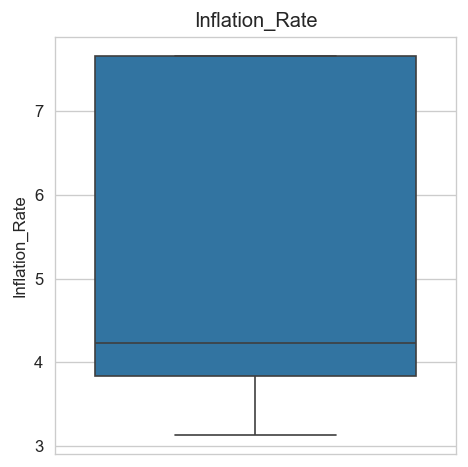

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group 1
group1 = ['Price']
fig, axes = plt.subplots(1, len(group1), figsize=(4*len(group1), 4))
axes = axes if len(group1) > 1 else [axes]
for ax, col in zip(axes, group1):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Group 2
group2 = ['Est_Delivery_Cost', 'CPI_Value']
fig, axes = plt.subplots(1, len(group2), figsize=(4*len(group2), 4))
axes = axes if len(group2) > 1 else [axes]
for ax, col in zip(axes, group2):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Group 3
group3 = ['Inflation_Rate']
fig, axes = plt.subplots(1, len(group3), figsize=(4*len(group3), 4))
axes = axes if len(group3) > 1 else [axes]

for ax, col in zip(axes, group3):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

 

## 2.3 Outlier Handling Using the IQR Method

To reduce the influence of extreme values that may distort statistical analysis, outlier handling is performed using the Interquartile Range (IQR) method (Tukey’s fences). This method identifies observations that fall significantly outside the typical range of each numerical variable.

Outlier removal is applied only to selected cost-related variables (`Price` and `Est_Delivery_Cost`). Variables such as `Year`, `CPI_Value`, and `Inflation_Rate` are intentionally excluded, as they represent official economic indicators rather than sampled observations.

Outliers are removed at the observation level in a sequential manner. The number of removed observations is reported for transparency and reproducibility.


In [74]:
import pandas as pd
# ==========================================
# 2. DATA CLEANING: OUTLIER HANDLING (IQR)
# ==========================================
def remove_outliers_iqr_iterative(df, column):
    df_filtered = df.copy()
    while True:
        Q1 = df_filtered[column].quantile(0.25)
        Q3 = df_filtered[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        prev_len = len(df_filtered)
        df_filtered = df_filtered[(df_filtered[column] >= lower_bound) & (df_filtered[column] <= upper_bound)]
        if len(df_filtered) == prev_len:
            break
    return df_filtered
# ==========================================
# EXECUTION
# ==========================================
# Columns selected for outlier handling
# NOTE:
# - 'Price' and 'Est_Delivery_Cost' represent sampled cost variables
# - 'Year', 'CPI_Value', and 'Inflation_Rate' are excluded as official indicators
cols_to_clean = ["Price", "Est_Delivery_Cost"]

print(f"Rows before outlier handling: {len(df)}")

for col in cols_to_clean:
    if col in df.columns:
        previous_size = len(df)
        df = remove_outliers_iqr(df, col)
        removed = previous_size - len(df)
        print(f" - {removed} observations removed from '{col}'")

print(f"Rows after outlier handling:  {len(df)}")


Rows before outlier handling: 1472
 - 6 observations removed from 'Price'
 - 0 observations removed from 'Est_Delivery_Cost'
Rows after outlier handling:  1466


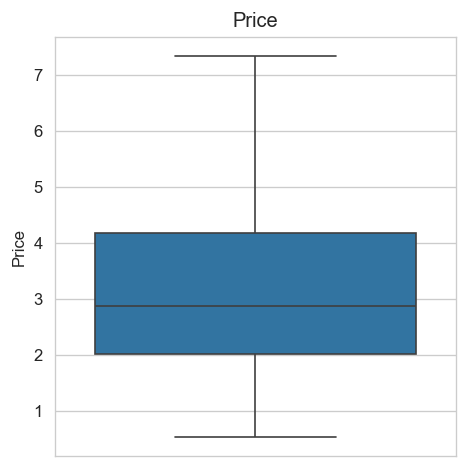

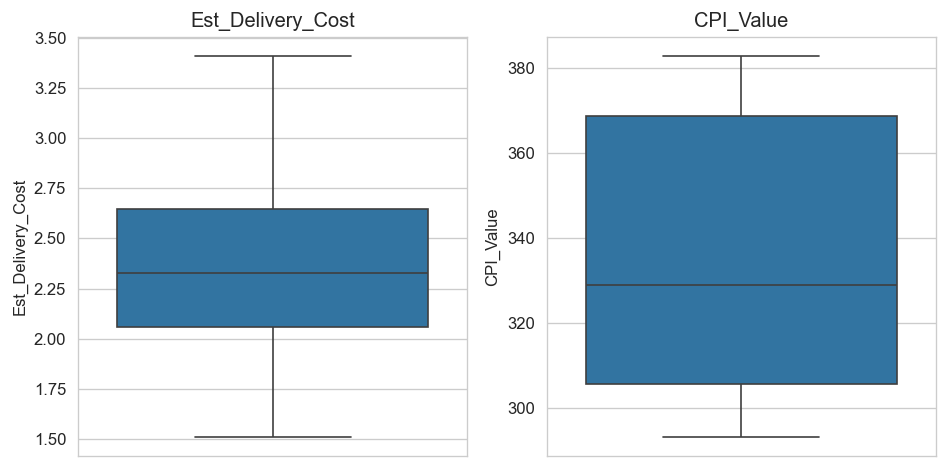

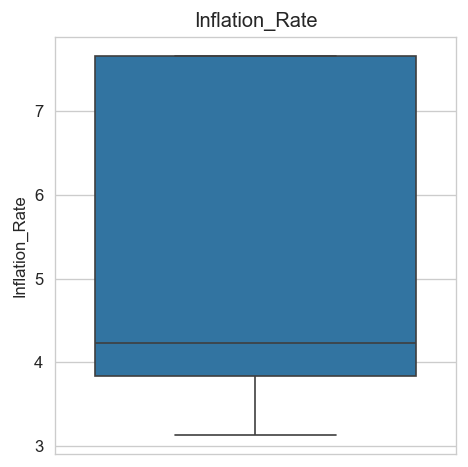

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group 1
group1 = ['Price']
fig, axes = plt.subplots(1, len(group1), figsize=(4*len(group1), 4))
axes = axes if len(group1) > 1 else [axes]
for ax, col in zip(axes, group1):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Group 2
group2 = ['Est_Delivery_Cost', 'CPI_Value']
fig, axes = plt.subplots(1, len(group2), figsize=(4*len(group2), 4))
axes = axes if len(group2) > 1 else [axes]
for ax, col in zip(axes, group2):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Group 3
group3 = ['Inflation_Rate']
fig, axes = plt.subplots(1, len(group3), figsize=(4*len(group3), 4))
axes = axes if len(group3) > 1 else [axes]

for ax, col in zip(axes, group3):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# 3. EDA( Explotary Data Analysis )
## 3.1 Univariate Analysis (Single Variable)


### 3.1.1 How are food prices distributed across observations, and are there indications of price dispersion or extreme values in the dataset?


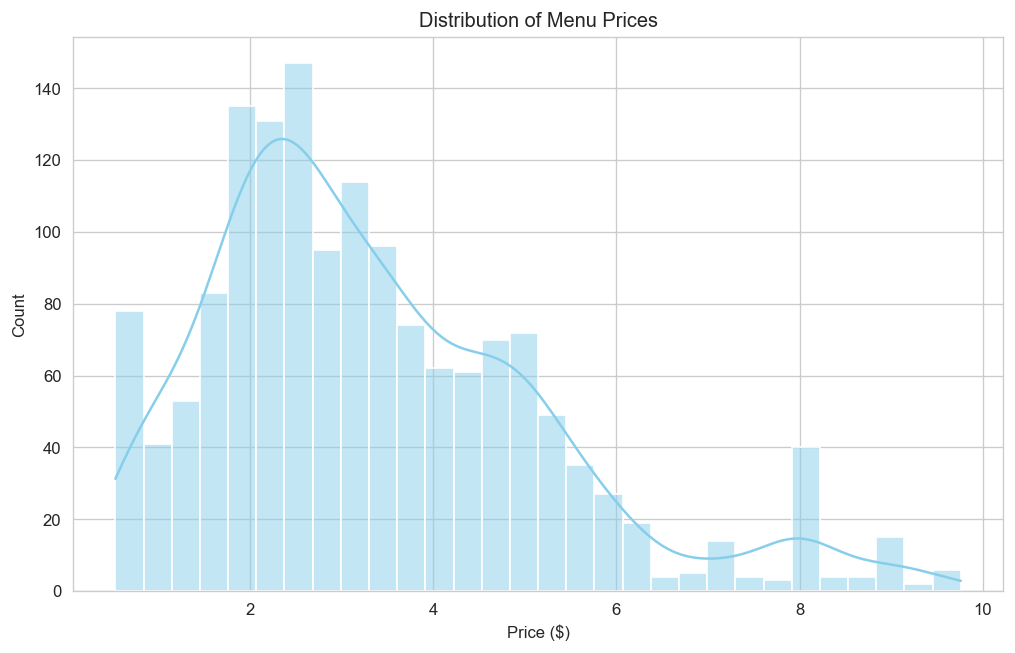

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Menu Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

**Interpretation:**  

The distribution of food prices is **right-skewed**, indicating that most menu and grocery items are concentrated in the **lower-to-mid price range**, while a smaller number of items are priced substantially higher.  

This pattern is typical of **cost-of-living data**, where premium food options and higher-cost urban areas introduce greater variability.  

The **smooth KDE curve** suggests a **unimodal distribution**, highlighting a **dominant price range across U.S. cities** after outlier removal.


### Distribution of Food Quality Scores (Ratings)

### 3.1.2 Question: How are food quality scores distributed across cities, and do most observations cluster within specific quality ranges?


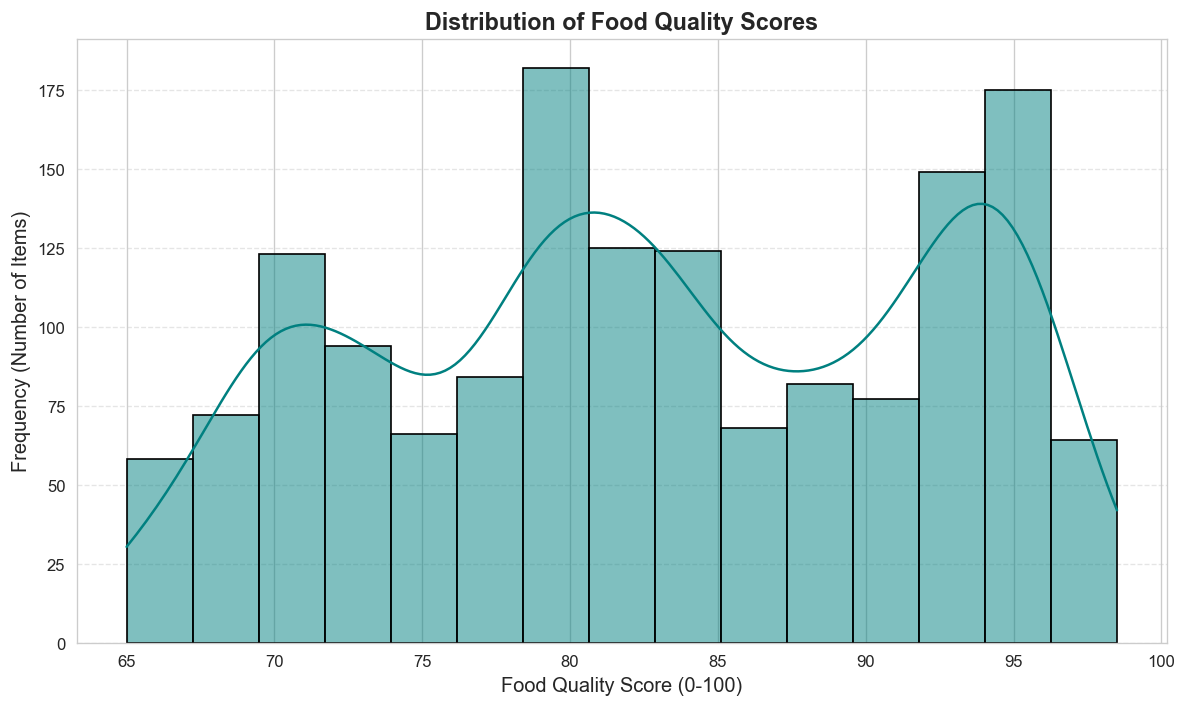

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
# We use 'histplot' because 'Food_Quality_Score' is numerical/continuous.
# 'kde=True' adds a smooth curve to show the overall trend.
sns.histplot(
    data=df, 
    x='Food_Quality_Score', 
    bins=15,           # Groups data into 15 ranges for cleaner viewing
    kde=True,          # Adds the Density Curve
    color='teal',
    edgecolor='black'  # Adds definition to the bars
)
# Formatting
plt.title("Distribution of Food Quality Scores", fontsize=14, fontweight='bold')
plt.xlabel("Food Quality Score (0-100)", fontsize=12)
plt.ylabel("Frequency (Number of Items)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Interpretation:**  

The distribution of food quality scores is **moderately spread across the upper range** of the scale, with a noticeable concentration between approximately **75 and 95**. This suggests that most cities in the dataset exhibit relatively **high food quality levels**.  

The **smooth KDE curve** indicates a **multimodal tendency**, reflecting variation in quality scores across different urban environments. Such variation is expected, as food quality is influenced by **city-specific factors** such as restaurant diversity, income levels, and consumer preferences.


### 3.1.3 Question:  What is the distribution of estimated delivery costs, and do delivery-related expenses vary substantially across observations?


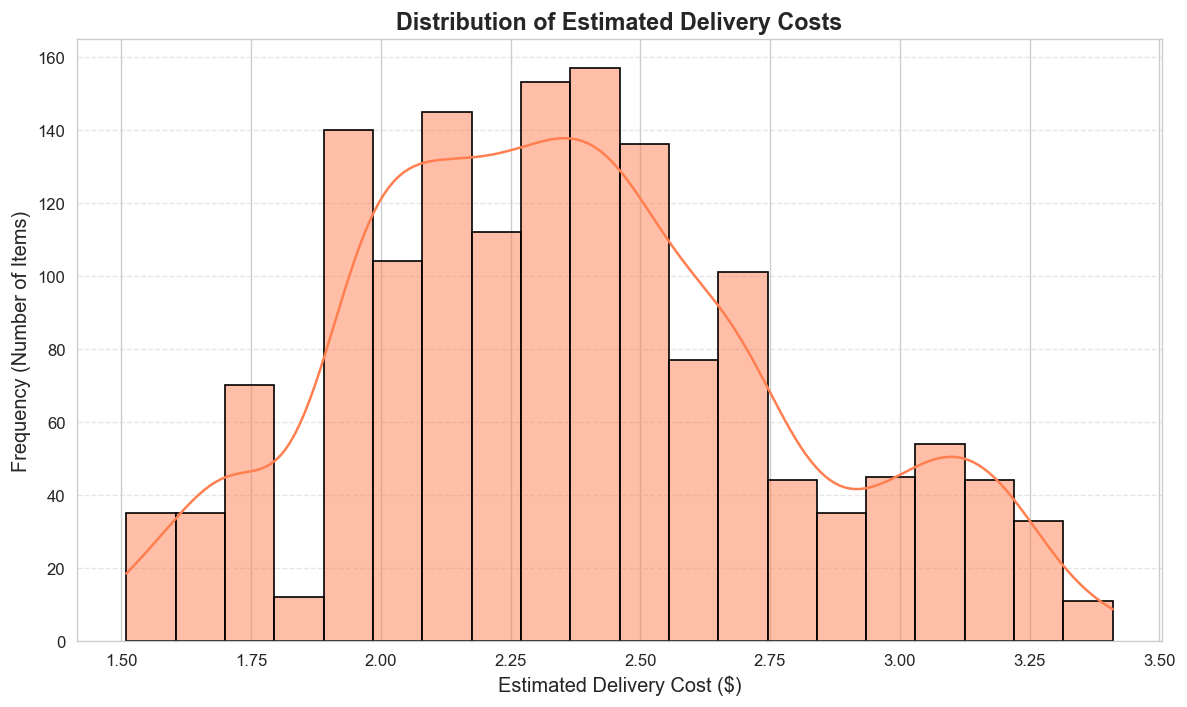

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 4.1.3 UNIVARIATE ANALYSIS:
#     DISTRIBUTION OF ESTIMATED DELIVERY COST
# ==========================================

plt.figure(figsize=(10, 6))

# We use a histogram because 'Est_Delivery_Cost' is a continuous numerical variable.
# KDE is added to visualize the overall distribution trend.
sns.histplot(
    data=df,
    x='Est_Delivery_Cost',
    bins=20,            # Slightly higher bins to capture cost variability
    kde=True,           # Adds a smooth density curve
    color='coral',
    edgecolor='black'
)

# Formatting
plt.title(
    "Distribution of Estimated Delivery Costs",
    fontsize=14,
    fontweight='bold'
)
plt.xlabel("Estimated Delivery Cost ($)", fontsize=12)
plt.ylabel("Frequency (Number of Items)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Interpretation**  

The distribution of estimated delivery costs is **moderately right-skewed**, with most observations concentrated between approximately **$2.00 and $2.60**. This suggests that delivery-related costs remain relatively **stable across cities**, with limited extreme variation.  

The presence of a **longer right tail** indicates that some cities experience **higher delivery costs**, likely driven by transportation prices, urban congestion, or higher fuel costs.  

Overall, the **unimodal shape** of the distribution reflects a **consistent delivery cost structure** across U.S. cities after data cleaning.


## 3.2 Bivaraite Analysis

### 3.2.1 Price Comparison Across Food Categories
Question: Are healthier menu options consistently more expensive than fast-food alternatives?

C:\Users\alfateh\AppData\Local\Temp\ipykernel_11364\3872124400.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='Category', y='Price', palette='Set2')


<Axes: xlabel='Category', ylabel='Price'>

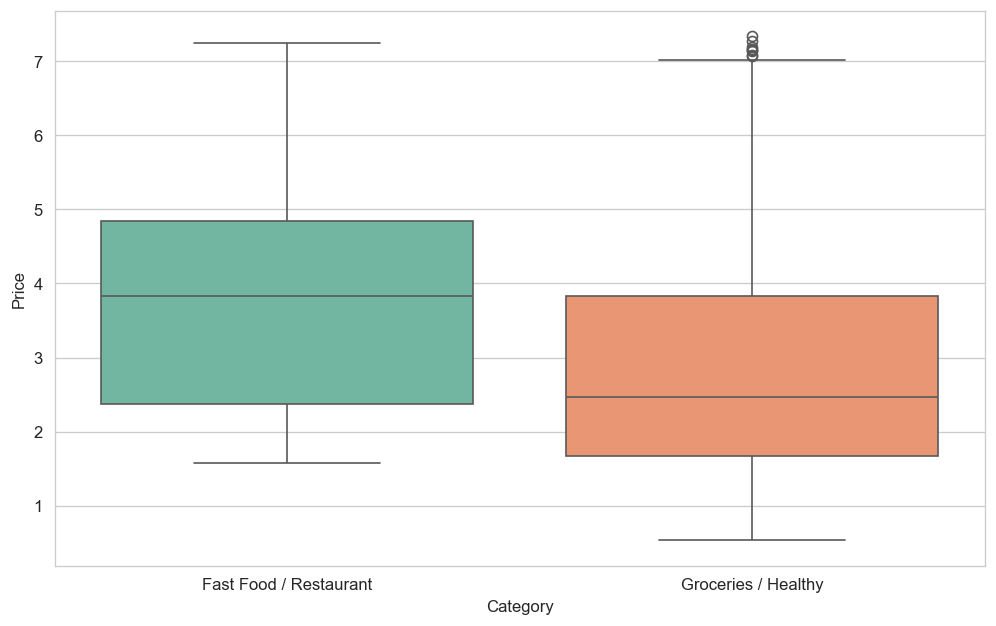

In [21]:
# Filter to include only specific categories
filtered_df = df[df['Category'].isin(['Fast Food / Restaurant', 'Groceries / Healthy'])]

# Use filtered_df in your boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df, x='Category', y='Price', palette='Set2')

#### The Prepared Meal Premium
The **Fast Food / Restaurant** category is significantly more expensive, with a median price nearly **double** that of grocery items.  

#### Broad Price Spectrum
The **Fast Food** category shows a very tall box (Large Interquartile Range), meaning there is a massive difference between a simple side item and a premium meal combo.  

#### Specialty Grocery Outliers
While **Groceries / Healthy** is the more budget-friendly category, it contains numerous **high-price outliers**. This suggests that while basic staples are cheap, "healthy" or organic specialty items can sometimes cost as much as a restaurant entree.  

#### Cost Overlap
The "whiskers" of the two plots **overlap significantly between $2.00 and $7.00**, indicating that a high-end grocery purchase often sits in the same price bracket as a standard fast-food meal.


 
### 3.2.2 Is there an observable relationship between food prices and food quality scores across U.S. cities?

In [33]:
import plotly.express as px

# ==========================================
# BIVARIATE ANALYSIS:
# PRICE VS. FOOD QUALITY SCORE
# ==========================================

# --------------------------------------------------
# 1. Data Preparation
# --------------------------------------------------
# Reset index to ensure a clean, flat DataFrame structure.
# This avoids potential indexing issues during visualization
# and ensures all columns are directly accessible.
df_viz = df.reset_index(drop=True)

# --------------------------------------------------
# 2. Create Interactive Scatter Plot
# --------------------------------------------------
# Purpose:
# - Examine the relationship between food prices and food quality scores
# - Identify patterns, dispersion, and potential non-linear trends
# - Enable interactive exploration by item, city, and category
#
# X-axis  : Food_Quality_Score (independent variable)
# Y-axis  : Price (dependent variable)
# Color   : Price intensity
# Size    : Price magnitude (visual emphasis)
fig = px.scatter(
    df_viz,
    x='Food_Quality_Score',
    y='Price',
    hover_data=['Item', 'City', 'Category'],  # Contextual info on hover
    color='Price',                            # Continuous color scale by price
    size='Price',                             # Bubble size reflects price level
    size_max=20,                              # Prevents excessive bubble overlap
    color_continuous_scale='Viridis',         # Perceptually uniform color scale
    opacity=0.7,                              # Improves visibility in dense areas
    title='Price Variation Across Food Quality Scores'
)

# --------------------------------------------------
# 3. Layout and Styling
# --------------------------------------------------
# Clean, professional layout suitable for academic reports
fig.update_layout(
    xaxis_title='Food Quality Score (0–100)',
    yaxis_title='Price (USD)',
    template='plotly_white',                  # Minimalist academic theme
    font=dict(family="Arial", size=12),
    height=600
)

# --------------------------------------------------
# 4. Display the Figure
# --------------------------------------------------
fig.show()


**Interpretation:**  

The scatter plot reveals a weak-to-moderate positive association between food quality scores and prices.

- Higher quality scores are often associated with higher-priced items, but the relationship is not strictly linear.
- A wide vertical spread at each quality score indicates that price is influenced by additional factors such as city, category, and delivery costs.
- The color and size encoding confirms that high-priced items are more concentrated at higher quality scores, though affordable options still exist across most quality levels.

**Conclusion:**  

While food quality contributes to price differences, it does not fully explain price variability, highlighting the multidimensional nature of cost-of-living dynamics.


## 3.3 Multivariate analysis

 

### 3.3.1 Do delivery prices reflect inflation over time?

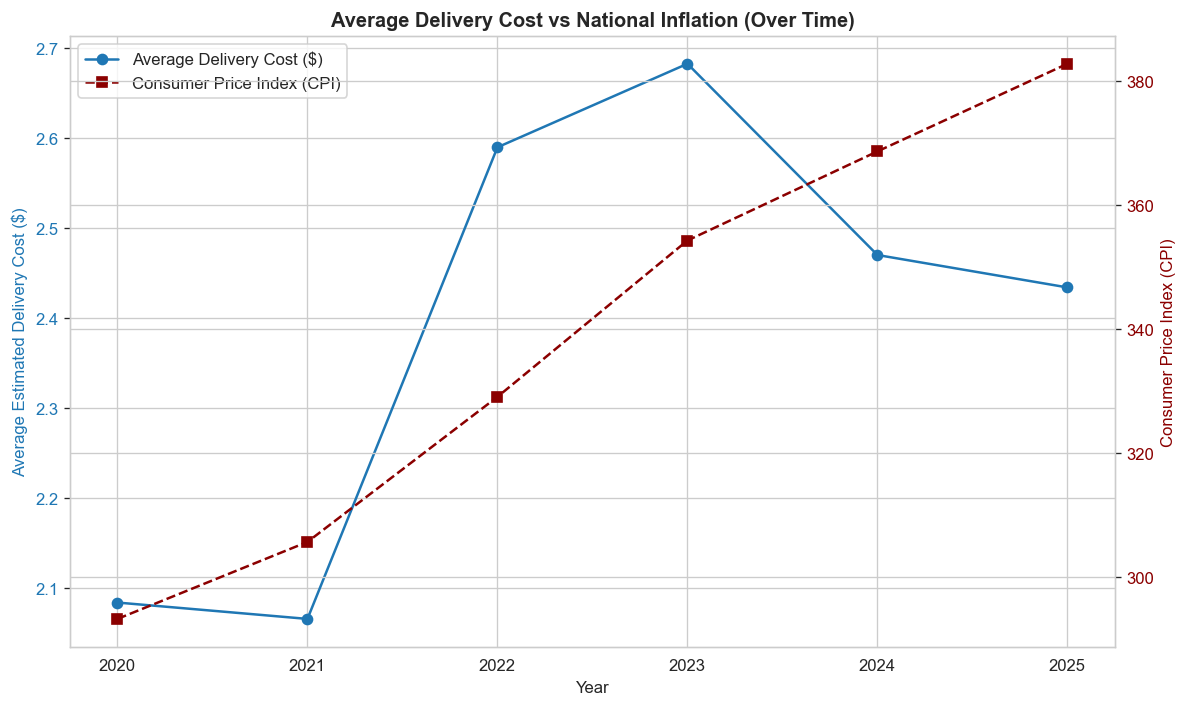

Correlation (Avg Delivery Cost vs CPI): 0.688


In [23]:
import matplotlib.pyplot as plt

# ==========================================
# Q1: Average Delivery Cost vs Inflation
# ==========================================

# Aggregate average delivery cost by year
avg_delivery = df.groupby("Year")["Est_Delivery_Cost"].mean().reset_index()

# Merge with CPI data
inflation_df = cpi_df.copy()
merged = avg_delivery.merge(inflation_df, on="Year", how="left")

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# ---- Left axis: Delivery Cost ----
line1 = ax1.plot(
    merged["Year"],
    merged["Est_Delivery_Cost"],
    marker="o",
    color="tab:blue",
    label="Average Delivery Cost ($)"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Estimated Delivery Cost ($)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# ---- Right axis: CPI ----
ax2 = ax1.twinx()
line2 = ax2.plot(
    merged["Year"],
    merged["CPI_Value"],
    linestyle="--",
    marker="s",
    color="darkred",
    label="Consumer Price Index (CPI)"
)
ax2.set_ylabel("Consumer Price Index (CPI)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

# ---- Title ----
plt.title("Average Delivery Cost vs National Inflation (Over Time)", fontweight="bold")

# ---- Combined Legend ----
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

# ---- Correlation ----
corr = merged["Est_Delivery_Cost"].corr(merged["CPI_Value"])
print(f"Correlation (Avg Delivery Cost vs CPI): {corr:.3f}")


**Interpretation**

This figure compares the evolution of average estimated delivery costs with the national Consumer Price Index (CPI) from 2020 to 2025.

Both series show a general upward trend, particularly between 2021 and 2023, indicating that delivery costs rise alongside national inflation.

The strongest increase in delivery costs coincides with the sharp CPI rise in 2022–2023, suggesting inflationary transmission into delivery pricing.

After 2023, delivery costs decline slightly while CPI continues to rise, implying that delivery prices do not fully mirror inflation in later years.

The reported positive correlation (~0.70) indicates a moderately strong relationship, but also confirms the presence of other influencing factors (e.g., platform fees, operational efficiency, competition).

**Conclusion:**
Average food delivery prices partially reflect national inflation trends over time, but inflation alone does not fully explain delivery cost dynamics.









 

### 3.3.2 Do restaurant ratings (food quality scores) influence menu price inflation rates?

C:\Users\alfateh\AppData\Local\Temp\ipykernel_11364\775158852.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Year", "Quality_Group"])


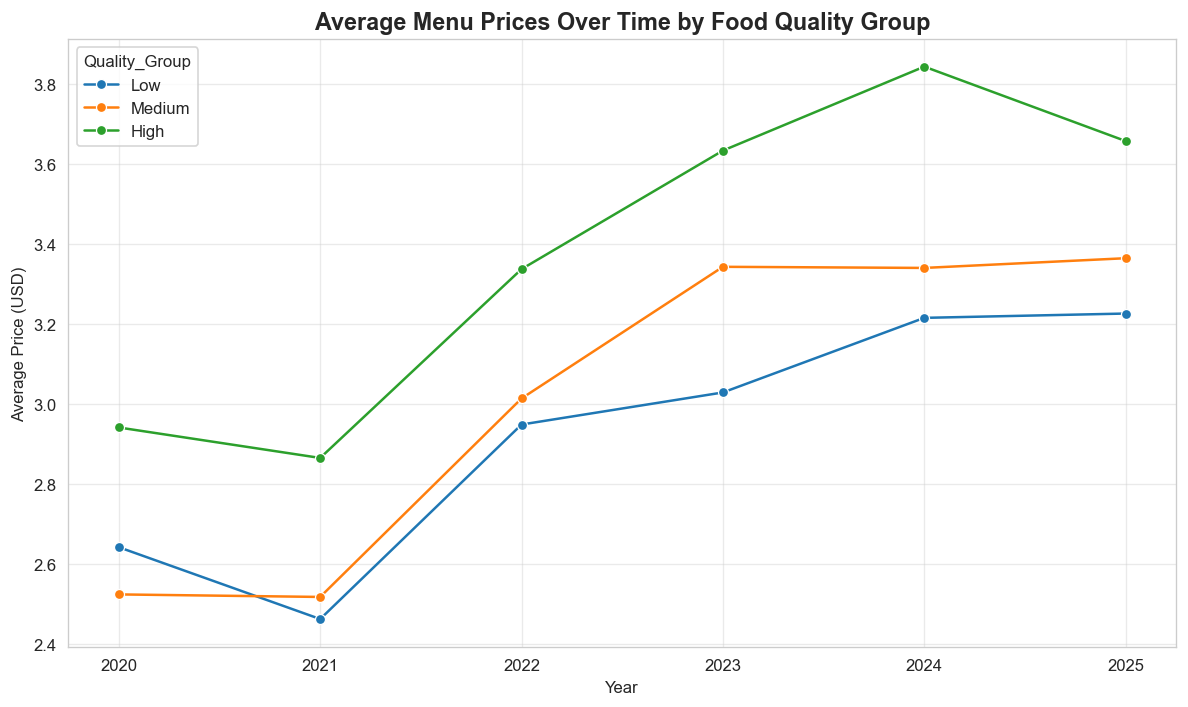

C:\Users\alfateh\AppData\Local\Temp\ipykernel_11364\775158852.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q3_df.groupby("Quality_Group")["Avg_Price"].pct_change() * 100


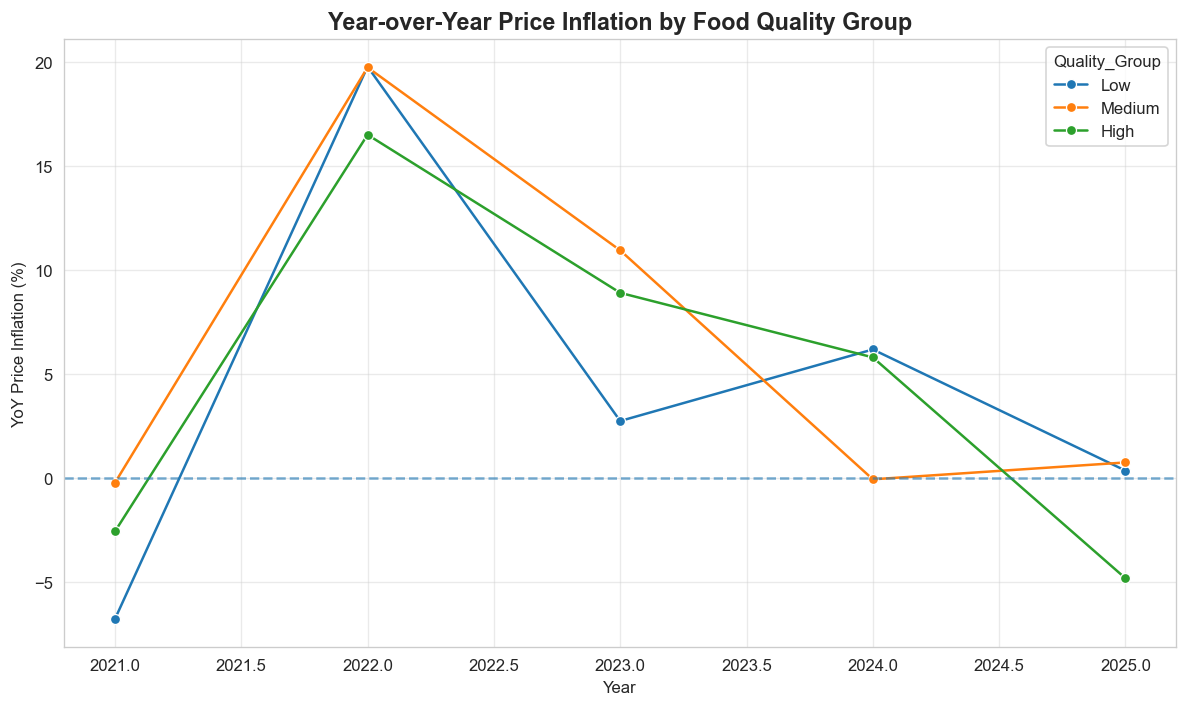

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================
# Q3: FOOD QUALITY VS PRICE INFLATION
# ==========================================

# Create quality groups
df["Quality_Group"] = pd.cut(
    df["Food_Quality_Score"],
    bins=[0, 75, 85, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Aggregate yearly average prices by quality group
q3_df = (
    df.groupby(["Year", "Quality_Group"])
      .agg(Avg_Price=("Price", "mean"))
      .reset_index()
      .sort_values(["Quality_Group", "Year"])
)

# ---- Line plot: price trends by quality ----
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=q3_df,
    x="Year",
    y="Avg_Price",
    hue="Quality_Group",
    marker="o"
)

plt.title(
    "Average Menu Prices Over Time by Food Quality Group",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# ---- Year-over-Year inflation by quality group ----
q3_df["YoY_Price_Inflation_%"] = (
    q3_df.groupby("Quality_Group")["Avg_Price"].pct_change() * 100
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=q3_df,
    x="Year",
    y="YoY_Price_Inflation_%",
    hue="Quality_Group",
    marker="o"
)

plt.axhline(0, linestyle="--", alpha=0.6)
plt.title(
    "Year-over-Year Price Inflation by Food Quality Group",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Year")
plt.ylabel("YoY Price Inflation (%)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


#### Average Menu Prices Over Time by Food Quality Group  
**Interpretation**

This figure illustrates the evolution of average menu prices for **Low**, **Medium**, and **High** food quality groups between **2020 and 2025**.

Across the entire time period, higher food quality is consistently associated with **higher average prices**, indicating a persistent price premium for higher-quality offerings.

A pronounced increase in prices is observed between **2021 and 2023**, particularly within the **High-quality** group. This trend aligns with broader **inflationary pressures** and rising operational costs affecting the food service sector during this period.

Following the peak around **2023–2024**, average prices **stabilize or slightly decline**, most notably in the **Low** and **Medium** quality groups. Despite this moderation, the relative ordering of prices across quality tiers remains unchanged.

The sustained separation between quality groups suggests that price differences are **structural rather than temporary**, with higher-quality menu items maintaining a long-term cost premium.

**Conclusion:**  
Higher-quality and healthier menu options are consistently priced above lower-quality alternatives, and this price gap remains stable over time rather than converging.


#### Year-over-Year Price Inflation by Food Quality Group

**Interpretation**

This figure illustrates the year-over-year percentage change in menu prices across three food quality groups: Low, Medium, and High.

- All quality groups experienced a sharp inflation spike in 2022, reflecting the broader post-pandemic inflation shock.
- High-quality food options exhibit the largest inflation increase in 2022, indicating greater price sensitivity to cost shocks such as ingredient quality, supply chain disruptions, and premium positioning.
- In 2023, price inflation moderates for High-quality items, while Medium-quality items continue to experience relatively elevated inflation.
- By 2024–2025, inflation rates decline or turn slightly negative across groups, suggesting price stabilization and partial correction after earlier increases.
- Low-quality items show the most stable inflation path overall, with smaller fluctuations compared to Medium and High categories.

**Conclusion:**  
Restaurant ratings (quality level) influence menu price inflation rates, with higher-quality food items experiencing stronger and more volatile inflation responses over time.


### 3.3.3 Corelation Analysis

--- Data Preview ---
   Year      City                Category                            Item  \
2  2020  New-York  Fast Food / Restaurant            Cappuccino (regular)   
3  2020  New-York  Fast Food / Restaurant  Coke/Pepsi (0.33 liter bottle)   
4  2020  New-York     Groceries / Healthy      Milk (regular), (1 gallon)   
5  2020  New-York     Groceries / Healthy            Rice (white), (1 lb)   
6  2020  New-York     Groceries / Healthy             Eggs (regular) (12)   

   Price  Food_Quality_Score  Est_Delivery_Cost  CPI_Value  Inflation_Rate  \
2   4.90                96.0               2.08    293.219        3.131375   
3   2.28                96.0               2.08    293.219        3.131375   
4   1.18                96.0               2.08    293.219        3.131375   
5   6.31                96.0               2.08    293.219        3.131375   
6   3.69                96.0               2.08    293.219        3.131375   

  Quality_Group  
2          High  
3          

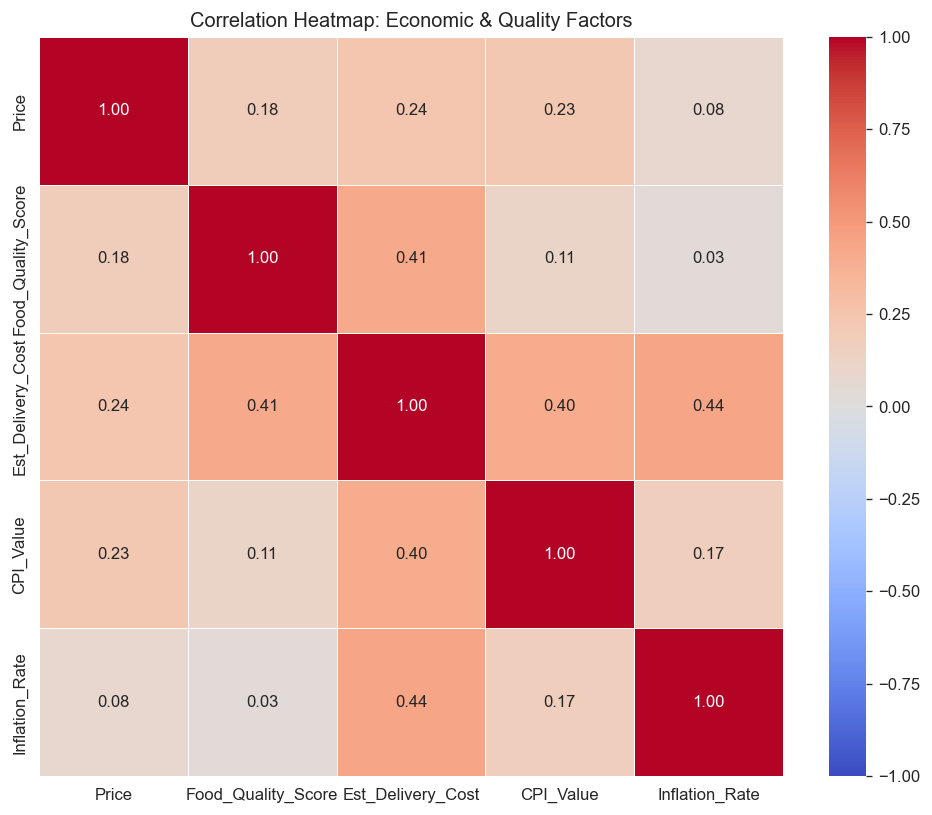


Unique Inflation Rate Values: 6


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 5. CORRELATION ANALYSIS
# ==========================================

# 1. Inspect the first few rows to ensure data is ready
print("--- Data Preview ---")
print(df.head())

# 2. Define the columns for correlation analysis
# Mapping your original request to our actual dataset columns:
# 'Branch_Rating' -> 'Food_Quality_Score'
# 'Review_Count'  -> 'Est_Delivery_Cost'
# 'National_CPI'  -> 'CPI_Value'
target_cols = [
    'Price', 
    'Food_Quality_Score', 
    'Est_Delivery_Cost', 
    'CPI_Value', 
    'Inflation_Rate'
]

# 3. Calculate Correlation
# We filter 'df' to only these columns before calling .corr()
corr_matrix = df[target_cols].corr()

print("\n--- Correlation Matrix (Numerical) ---")
print(corr_matrix)

# 4. Visualize with a Heatmap (Professional Standard)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,        # Show the numbers in the squares
    cmap='coolwarm',   # Red = Positive Corr, Blue = Negative Corr
    fmt=".2f",         # Round to 2 decimal places
    linewidths=0.5,
    vmin=-1, vmax=1    # Fix scale from -1 to 1 for accuracy
)
plt.title("Correlation Heatmap: Economic & Quality Factors")
plt.show()

# 5. Check Variance in Inflation Data
# Checking how many unique inflation rates exist (should match # of years)
unique_inflation_counts = df['Inflation_Rate'].nunique()
print(f"\nUnique Inflation Rate Values: {unique_inflation_counts}")

#### 4.3.3 Do average food delivery prices reflect national inflation trends over time?  (need for revision)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# TEMPORAL AGGREGATION & CORRELATION ANALYSIS
# ==========================================

# Note: The scraper collects mid-year (June) data, so 'Year' serves as our temporal axis.
# If a 'Date_Collected' column exists, we ensure it is in datetime format.
if 'Date_Collected' in df.columns:
    df['Date_Collected'] = pd.to_datetime(df['Date_Collected'])
    df['Year'] = df['Date_Collected'].dt.year

# Group data by Year to calculate annual averages for economic indicators
# Mapped 'National_CPI' -> 'CPI_Value'
# Mapped 'National_Inflation_Rate' -> 'Inflation_Rate'
yearly_stats = (
    df.groupby('Year')[['Price', 'CPI_Value', 'Inflation_Rate']]
      .mean()
      .reset_index()
)

# Calculate Pearson Correlation coefficients to determine economic relationships
# Correlation between raw item prices and the Consumer Price Index (CPI)
corr_price_cpi = yearly_stats['Price'].corr(yearly_stats['CPI_Value'])

# Correlation between raw item prices and the annual Inflation Rate
corr_price_infl = yearly_stats['Price'].corr(yearly_stats['Inflation_Rate'])

# Display correlation results
print(f"Correlation (Price vs CPI Value): {corr_price_cpi:.3f}")
print(f"Correlation (Price vs Inflation Rate): {corr_price_infl:.3f}")

# Optional: Display the aggregated table for verification
print("\n--- Annual Economic Statistics ---")
print(yearly_stats)

Correlation (Price vs CPI Value): 0.952
Correlation (Price vs Inflation Rate): 0.297

--- Annual Economic Statistics ---
   Year     Price  CPI_Value  Inflation_Rate
0  2020  2.709451    293.219        3.131375
1  2021  2.647485    305.634        4.234037
2  2022  3.122653    329.033        7.655889
3  2023  3.405873    354.245        7.662453
4  2024  3.506409    368.616        4.056797
5  2025  3.443875    382.750        3.834343


### 3.3.4 Comparative Price Distribution by Food Category Across Top 3 Cities

<Axes: xlabel='Category', ylabel='Price'>

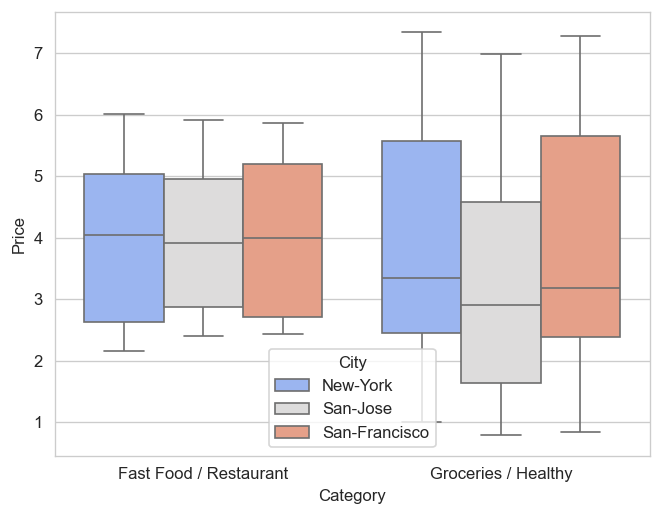

In [36]:
# 1. Identify the top 5 cities by mean price
filtered_df = df[df['Category'].isin(['Fast Food / Restaurant', 'Groceries / Healthy'])]
top_3_expensive = filtered_df.groupby('City')['Price'].mean().nlargest(3).index

# 2. Filter the original dataframe
filtered_df_top_5 = filtered_df[filtered_df['City'].isin(top_5_expensive)]

# 3. Use df_top5 in your boxplot code
sns.boxplot(x='Category', y='Price', hue='City', data=filtered_df_top_5, palette='coolwarm')


#### 1. Fast Food / Restaurant

This category demonstrates **high price stability** across all three cities, as indicated by the **narrow interquartile ranges** (compact box heights), suggesting consistent pricing within this segment.

- **New York (Blue):**  
  Records the **highest median price**, approximately **$4.05**, indicating generally higher costs for fast food and restaurant items.

- **San Francisco (Orange):**  
  Closely follows New York with a median of around **$4.00**, while exhibiting a slightly higher **minimum price**, suggesting fewer low-cost options.

- **San Jose (Grey):**  
  The **most affordable city** in this category, with a median price of approximately **$3.90**, reflecting more competitive pricing.

---

#### 2. Groceries / Healthy

This category shows **substantially higher price volatility**, evidenced by **taller box plots** and wider ranges between minimum and maximum prices.

- **New York (Blue):**  
  Maintains the **highest median price** at roughly **$3.40**, with premium items exceeding **$7.00**, highlighting a wide range of product pricing.

- **San Francisco (Orange):**  
  Displays a similar upper price range to New York but a lower median of approximately **$3.20**, indicating slightly better affordability on average.

- **San Jose (Grey):**  
  Continues to be the **most budget-friendly option**, with a median price near **$2.90** and the **lowest overall prices**, in some cases dropping below


##  4 Predicting Est Delivery Cost by Applying Linear Regression

In [59]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score


# 2. Define features and target
X = df.select_dtypes(include=np.number).drop('Est_Delivery_Cost',axis=1)

y = df['Est_Delivery_Cost']

# 3. Split into train and test sets (optional but recommended)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions
y_pred = lr_model.predict(X_test)

# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
 

print("Model Coefficients:", lr_model.coef_)
print("Model Intercept:", lr_model.intercept_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Model Coefficients: [-0.2383633   0.02433159  0.0159484   0.01612129  0.07728595]
Model Intercept: 477.21967616372507
Mean Squared Error: 0.10281036190392741
R² Score: 0.4273041404227498


## Baseline Linear Regression Model (Before Feature Engineering)

A baseline Linear Regression model was developed to predict **Estimated Delivery Cost** using the available numerical features. All features were standardized prior to model fitting to ensure numerical stability and to allow meaningful comparison of coefficient magnitudes.

---

### Model Performance

- **Mean Squared Error (MSE):** 0.1028  
- **R² Score:** 0.4273  

The model explains approximately **42.7% of the variance** in the estimated delivery cost, indicating a **moderate level of predictive performance**.

---

### Model Coefficients (Standardized Features)

| Feature               | Coefficient |
|----------------------|-------------|
| Year                 | −0.2384     |
| Price                | +0.0243     |
| Food_Quality_Score   | +0.0159     |
| CPI_Value            | +0.0161     |
| Inflation_Rate       | +0.0773     |

Positive coefficients indicate that increases in the corresponding feature are associated with higher estimated delivery costs, while negative coefficients indicate an inverse relationship.

---

### Interpretation

Among the examined variables, **Inflation Rate** exhibits the strongest positive influence on estimated delivery cost, reflecting the impact of macroeconomic conditions. **Price** and **Food Quality Score** show relatively weak direct effects. The negative coefficient for **Year** suggests a downward trend in delivery costs over time when controlling for other factors.

---

### Limitations

Despite reasonable performance, a significant portion of variability remains unexplained. This is likely due to the absence of operational and contextual factors such as delivery distance, traffic conditions, time of day, and platform-specific pricing mechanisms.

---

This baseline model provides a clear **reference point** for assessing the impact of subsequent **feature engineering and model refinement**.
